# Praktikum Analisis Citra Digital: Segmentasi Citra (CPMK041)
**Tujuan:** Menganalisis persoalan computing kompleks melalui teknik deteksi tepi, Hough Transform, Region-based segmentation, dan Watershed.

**Materi Utama:**
1. Edge Detection (Sobel & Canny)
2. Hough Transform (Lines & Circles)
3. Region Growing & Split-Merge
4. Watershed Algorithm
5. Evaluasi Kualitas (IoU Score)

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import segmentation, color, feature
from skimage.measure import label, regionprops
from skimage.segmentation import flood_fill

# Fungsi utilitas untuk menampilkan gambar agar lebih rapi
def plot_comparison(img1, title1, img2, title2, cmap='gray'):
    plt.figure(figsize=(12, 6))
    plt.subplot(121), plt.imshow(img1, cmap=cmap), plt.title(title1)
    plt.subplot(122), plt.imshow(img2, cmap=cmap), plt.title(title2)
    plt.show()

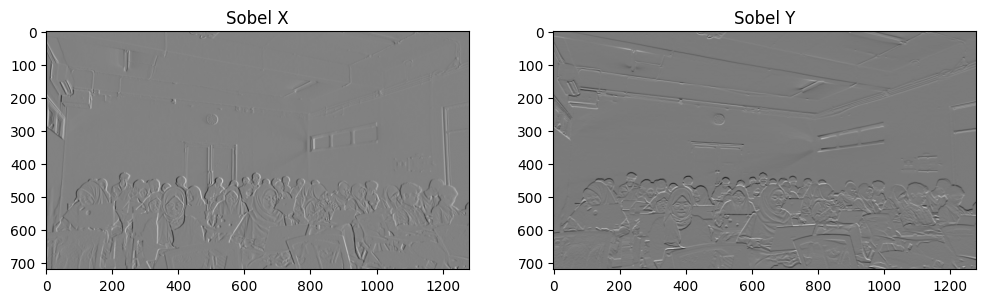

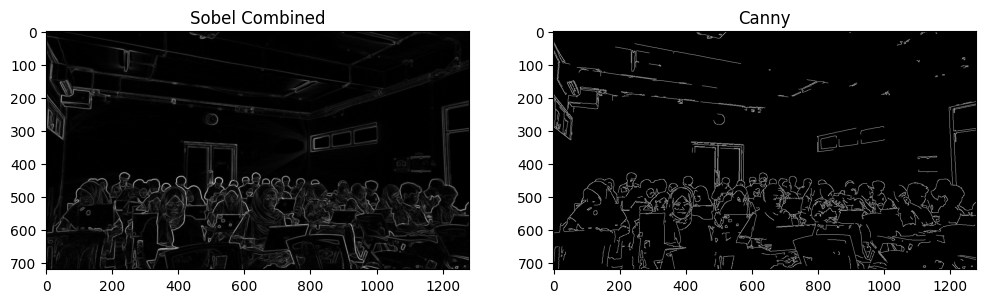

In [ ]:
# Load citra (gunakan citra grayscale untuk deteksi tepi)
# Gantilah 'image.jpg' dengan file yang ada di komputermu
img = cv2.imread('kelas.jpg', 0)

# 1. Sobel Edge Detection
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)
sobel_combined = cv2.magnitude(sobelx, sobely)

# 2. Canny Edge Detection
canny = cv2.Canny(img, 100, 200)

plot_comparison(sobelx, 'Sobel X', sobely, 'Sobel Y')
plot_comparison(sobel_combined, 'Sobel Combined', canny, 'Canny')

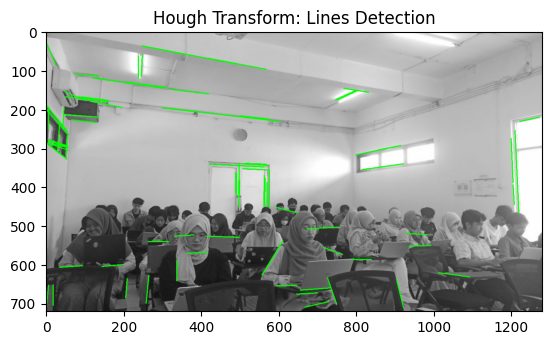

In [ ]:
# Gunakan hasil Canny untuk Hough Transform
lines = cv2.HoughLinesP(canny, 1, np.pi/180, threshold=50, minLineLength=50, maxLineGap=10)

img_lines = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.imshow(cv2.cvtColor(img_lines, cv2.COLOR_BGR2RGB))
plt.title('Hough Transform: Lines Detection')
plt.show()

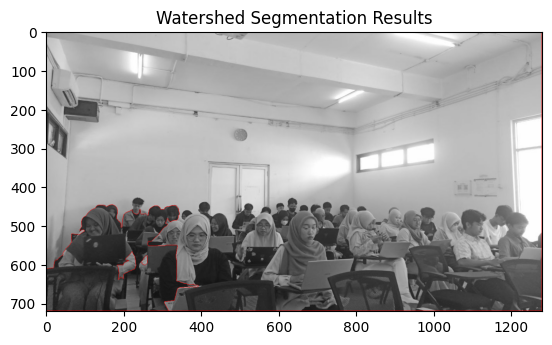

In [ ]:
# Segmentasi untuk objek yang saling bersentuhan
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Noise removal
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Mencari area background yang pasti
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Mencari area foreground yang pasti menggunakan Distance Transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)

# Marker labelling
sure_fg = np.uint8(sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[cv2.subtract(sure_bg, sure_fg) == 255] = 0

# Eksekusi Watershed
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(img_color, markers)
img_color[markers == -1] = [255, 0, 0] # Garis batas merah

plt.imshow(img_color)
plt.title('Watershed Segmentation Results')
plt.show()

In [ ]:
def calculate_iou(mask_gt, mask_pred):
    """Menghitung Intersection over Union (IoU)"""
    intersection = np.logical_and(mask_gt, mask_pred)
    union = np.logical_or(mask_gt, mask_pred)
    return np.sum(intersection) / np.sum(union)

# Contoh penggunaan sederhana (Dummy Masks)
gt = np.zeros((100, 100), dtype=bool)
gt[20:50, 20:50] = True

pred = np.zeros((100, 100), dtype=bool)
pred[25:55, 25:55] = True

print(f"Hasil Evaluasi IoU: {calculate_iou(gt, pred):.4f}")

Hasil Evaluasi IoU: 0.5319


### **Instruksi Tugas Mandiri**
1. Lakukan segmentasi pada citra medis atau citra industri pilihanmu.
2. Bandingkan metode **Region Growing** dengan **Split-Merge**.
3. Hitung akurasi hasil segmentasimu menggunakan **IoU Score** terhadap manual masking.
4. Berikan analisis mengapa satu algoritme bekerja lebih baik daripada yang lain pada citra tersebut.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


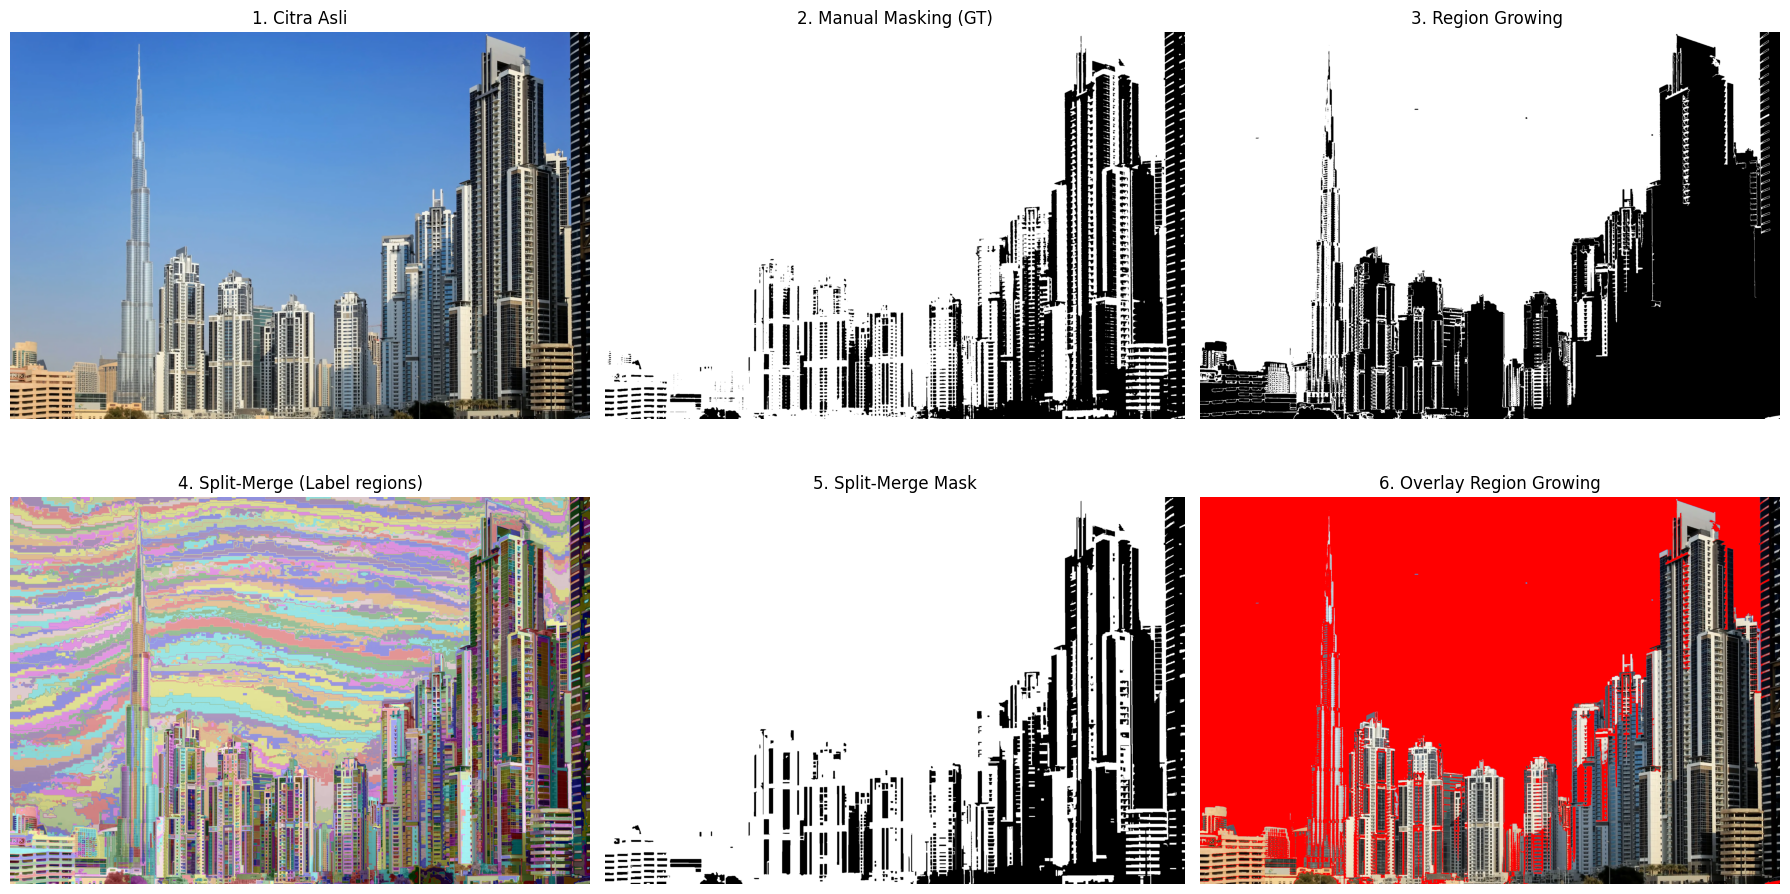

Optimized IoU Region Growing: 0.7714 (77.14%)
Optimized IoU Split-Merge:   0.9642 (96.42%)


In [72]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import segmentation, color

# 1. LOAD & PREPROCESS

# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    pass

img_path = '/content/drive/MyDrive/Pengolahan_Citra/bangunan.webp'

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
# Blur untuk mengurangi noise tekstur pada gedung
blurred = cv2.GaussianBlur(gray, (7, 7), 0)

# 2. MANUAL MASK (Ground Truth)
_, manual_mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 3. IMPROVED REGION GROWING
def region_growing_optimized(img, manual_ref, threshold=25):
    h, w = img.shape
    segmented = np.zeros((h, w), dtype=np.uint8)

    # Otomatisasi Seed: Mengambil koordinat dari Manual Mask secara menyebar
    coords = np.column_stack(np.where(manual_ref > 0))
    if len(coords) == 0:
        seeds = [(h//2, w//2)]
    else:
        # Ambil 5 sampel titik benih dari area gedung
        indices = np.linspace(0, len(coords)-1, 5).astype(int)
        seeds = [tuple(coords[i]) for i in indices]

    for seed in seeds:
        if segmented[seed] == 255: continue
        seed_value = int(img[seed])
        stack = [seed]

        while stack:
            x, y = stack.pop()
            if segmented[x, y] == 255: continue
            segmented[x, y] = 255

            for dx, dy in [(-1,0), (1,0), (0,-1), (0,1)]:
                nx, ny = x + dx, y + dy
                if 0 <= nx < h and 0 <= ny < w and segmented[nx, ny] == 0:
                    if abs(int(img[nx, ny]) - seed_value) < threshold:
                        stack.append((nx, ny))
    return segmented

region_mask = region_growing_optimized(blurred, manual_mask)

# 4. OPTIMIZED SPLIT & MERGE
def optimized_split_merge(img):
    # Menggunakan Felzenszwalb sebagai tahap 'Split'
    labels = segmentation.felzenszwalb(img, scale=100, sigma=0.5, min_size=50)
    result_mask = np.zeros_like(img)
    unique_labels = np.unique(labels)
    for l in unique_labels:
        mask = labels == l
        # Merge berdasarkan rata-rata intensitas area
        if np.mean(img[mask]) > 100:
            result_mask[mask] = 255
    return result_mask, color.label2rgb(labels, image_rgb, kind='overlay')

split_mask, split_raw_vis = optimized_split_merge(blurred)

# 5. IoU EVALUATION
def compute_iou(mask1, mask2):
    m1 = mask1 > 0
    m2 = mask2 > 0
    intersection = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return intersection / union if union != 0 else 0

iou_region = compute_iou(manual_mask, region_mask)
iou_split = compute_iou(manual_mask, split_mask)

# 6. VISUALISASI HASIL
plt.figure(figsize=(18, 10))

plt.subplot(2,3,1); plt.title("1. Citra Asli"); plt.imshow(image_rgb); plt.axis('off')
plt.subplot(2,3,2); plt.title("2. Manual Masking (GT)"); plt.imshow(manual_mask, cmap='gray'); plt.axis('off')
plt.subplot(2,3,3); plt.title(f"3. Region Growing "); plt.imshow(region_mask, cmap='gray'); plt.axis('off')
plt.subplot(2,3,4); plt.title("4. Split-Merge (Label regions)"); plt.imshow(split_raw_vis); plt.axis('off')
plt.subplot(2,3,5); plt.title(f"5. Split-Merge Mask"); plt.imshow(split_mask, cmap='gray'); plt.axis('off')

# Tambahkan overlay untuk mempermudah analisis visual
overlay_rg = image_rgb.copy()
overlay_rg[region_mask > 0] = [255, 0, 0]
plt.subplot(2,3,6); plt.title("6. Overlay Region Growing"); plt.imshow(overlay_rg); plt.axis('off')

plt.tight_layout()
plt.show()

print(f"Optimized IoU Region Growing: {iou_region:.4f} ({iou_region*100:.2f}%)")
print(f"Optimized IoU Split-Merge:   {iou_split:.4f} ({iou_split*100:.2f}%)")

<h1>Analisis</h1>
<h5>Split-Merge bekerja jauh lebih baik karena mampu memahami konteks spasial dan tekstur kelompok dari gedung pencakar langit. Sementara itu, Region Growing gagal mencapai skor maksimal karena mencoba menyelesaikan masalah segmentasi struktural yang kompleks hanya dengan mengandalkan perbandingan nilai piksel tetangga yang sangat lokal dan sensitif terhadap bayangan</h5>